# Worksheet: Forward Pass and Backward Propagation

**Topic:** Forward Pass, Loss, Backward Pass, and Training Dynamics

This worksheet is designed practice:
- the **forward pass**
- the **loss function**
- the **backward pass**
- the **learning rate**
- **epochs**, **batches**, and **optimizers**
- regularization ideas such as **dropout** and **L1/L2 penalties**


## Learning goals

By the end of this worksheet, you should be able to:

1. Explain what happens during the forward pass.
2. Compute predictions from weights, inputs, and activations.
3. Interpret a loss value.
4. Explain the role of gradients in the backward pass.
5. Describe the effect of the learning rate.
6. Distinguish batch, stochastic, and mini-batch gradient descent.
7. Build and train a small Keras model for regression and classification.
8. Interpret learning curves and regularization choices.

---

# 1. The forward pass

The **forward pass** is the process of moving information from:

**inputs → hidden layer(s) → output**

At each layer and for each neuron the model does two things:

1. Computes a weighted sum  
   $
   z = w^{\top}x + b
   $

   for a single neuron

2. Applies an activation function  
   $
   a = f(z)
   $

The output of one layer becomes the input to the next layer.

## Review: One neuron forward pass

Suppose a neuron receives:

- `x = [2.0, -1.0, 3.0]`
- `w = [0.5, 0.2, -0.4]`
- `b = 0.1`

Compute the weighted sum:
\[
z = w_1x_1 + w_2x_2 + w_3x_3 + b
\]

In [1]:
import numpy as np
## std variables
x = np.array([2.0, -1.0, 3.0])

## weights should be initialized closed to zero N(0,1), Glorot Normal N(0, )
## weights are called kernels (kernel initializer or weight initializer)
w = np.array([0.5, 0.2, -0.4])

## biases are generally intialized at zero
b = 0.1

z = w.dot(x) + b

print("z =", z)

z = -0.30000000000000016


In [3]:
## example of layers with initialization values

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense ## feed-forward

model = Sequential()
model.add(Input(shape = (3,)))
model.add(Dense(2, activation = "relu", kernel_initializer='glorot_uniform', bias_initializer='zeros'))
model.add(Dense(2, activation = "relu", kernel_initializer='glorot_uniform', bias_initializer='zeros'))
model.add(Dense(1))

model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

## Review: Apply ReLU in the forward pass

Now apply the ReLU activation:

$a = \max(0, z)$

In [4]:
def relu(z):
    return np.max((0, z))

a_relu = relu(z)

print("a_relu =", a_relu)

a_relu = 0.0


Now apply the Sigmoid activation:

$a = 1 / (1 + e^{-z})$

In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

a_sigmoid = sigmoid(z)

print("a_sigmoid =", a_sigmoid)

a_sigmoid = 0.4255574831883409


---

# 2. A small multi-layer forward pass

For multiple neurons in the process of forward pass:

**inputs → hidden layer(s) → output**

1. Computes a weighted sum  
   $
   z = xW + b
   $

   for a multiple neurons

2. Applies an activation function  
   $
   a = f(z)
   $

The output of one layer becomes the input to the next layer.



Consider a network with:

- 3 input values
- 2 neurons in the hidden layer
- 1 output neuron

We will manually compute the forward pass.

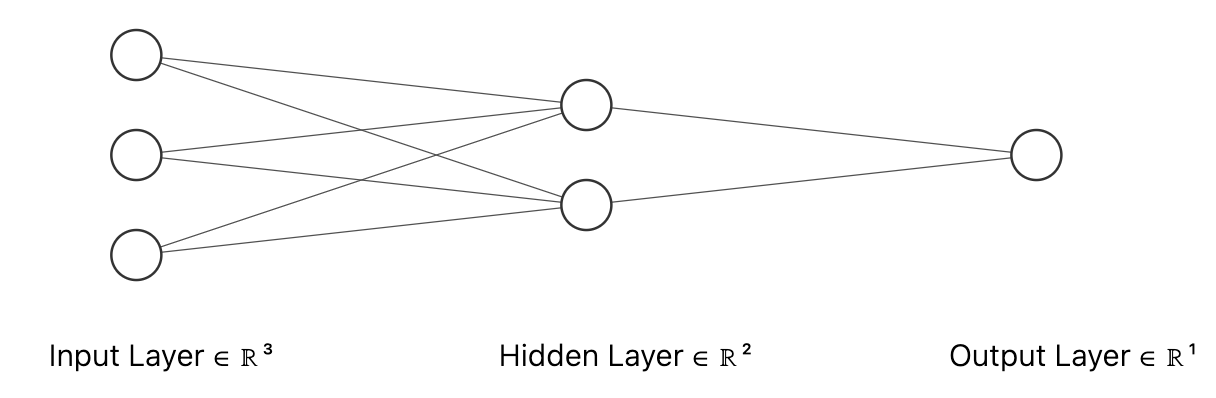

## Practice 2A: Hidden layer calculations

Use the following:

$$
x = [1.5, 2.0, -1.0]
$$

Hidden-layer weights:
$$
W^{[1]} =
\begin{bmatrix}
0.2 & -0.4 \\
0.7 & 0.1 \\
-0.5 & 0.3
\end{bmatrix}
$$

Hidden-layer biases:
$$
b^{[1]} = [0.1, -0.2]
$$

Compute:
1. `z1 = x @ W1 + b1` or `z1 = x.dot(W1) + b1`
2. `a1 = relu(z1)`

In [6]:
x = np.array([1.5, 2.0, -1.0])
W1 = np.array([
    [0.2, -0.4],
    [0.7,  0.1],
    [-0.5, 0.3]
])
b1 = np.array([0.1, -0.2])

## COMPUTE z1
#### The weights of each neuron are stacked in column of the W matrix
#### z is going to a vector of size (2,1)
z = x.dot(W1) + b1  ## z = x @ W1 + b1

z

array([ 2.3, -0.9])

In [7]:
## COMPUTE a1

#### output (activation) is also a vector of (2,1)
def relu(z):
  return np.maximum(0,z)

relu(z)

#### each column can be computed seperately (multi-core processing - GPU, CPU)
#### next layer cannot be processed on parallel, because we need the output of the previous layer

array([2.3, 0. ])

1. Compute a weighted sum  
   $
   z = XW + b
   $

   for multiple neurons and multiple observation

2. Applies an activation function  
   $
   a = f(z)
   $

In [8]:
## for a batch of obs
## they are stacked in a matrix

X = np.array([
    [1.5, 2.0, -1.0],
    [0.5, 1.0,  2.0],
    [2.0, -1.5, 1.0],
    [1.7, -2.1, 2.2]
])

W1 = np.array([
    [0.2, -0.4],
    [0.7,  0.1],
    [-0.5, 0.3]
])

b1 = np.array([0.1, -0.2])

# Compute Z1
Z1 = X.dot(W1) + b1
print(Z1)

[[ 2.3  -0.9 ]
 [-0.1   0.3 ]
 [-1.05 -0.85]
 [-2.13 -0.43]]


## Practice 2B: Output layer calculation

Now use:

$$
W^{[2]} =
\begin{bmatrix}
0.6 \\
-0.2
\end{bmatrix},
\quad
b^{[2]} = [0.05]
$$

Compute:
1. `z2 = a1 @ W2 + b2`
2. Because this is regression, use a **linear** activation, so `y_hat = z2`

In [9]:

W2 = np.array([
    [0.6],
    [-0.2]
])
b2 = np.array([0.05])

## define linear activation
def linear(z):
    return z

# TODO
z2 = Z1.dot(W2) + b2
y_hat = linear(z2)

print("z2 =", z2)
print("y_hat =", y_hat)

z2 = [[ 1.61 ]
 [-0.07 ]
 [-0.41 ]
 [-1.142]]
y_hat = [[ 1.61 ]
 [-0.07 ]
 [-0.41 ]
 [-1.142]]


---

# 3. Loss functions

After the forward pass produces predictions, the model compares the predictions to the true values using a **loss function**.

Examples:
- **MSE** for regression
- **binary crossentropy** for binary classification and multi-label classification
- **categorical crossentropy** for multi-class classification

## Practice 3A: Mean squared error

Suppose a model predicts house prices for 4 homes:

- true values: `[300, 420, 390, 510]`
- predictions: `[310, 400, 405, 480]`

Compute the mean squared error:
$
MSE = \frac{1}{n}\sum (y_i - \hat{y}_i)^2
$

In [12]:
y_true = np.array([300, 420, 390, 510], dtype=float)
y_pred = np.array([310, 400, 405, 480], dtype=float)

## define mse
from tensorflow.keras.losses import MeanSquaredError
mse = MeanSquaredError()

## calculate mse
mse_value = mse(y_true, y_pred)

print("MSE =", mse_value)

MSE = tf.Tensor(406.25, shape=(), dtype=float32)


Compute the binary crossentropy:
$
BCE = -\frac{1}{n}\sum_{i=1}^{n}\left[y_i\log(\hat{p}_i) + (1-y_i)\log(1-\hat{p}_i)\right]
$

In [14]:
# True labels and predicted probabilities
y_true = np.array([1, 0, 1, 1], dtype=float)
y_pred = np.array([0.90, 0.20, 0.75, 0.60], dtype=float)

# Define binary crossentropy
from tensorflow.keras.losses import binary_crossentropy

# Calculate binary crossentropy
bce_value = binary_crossentropy(y_true, y_pred)

print("Binary Crossentropy =", bce_value)

Binary Crossentropy = tf.Tensor(0.2817529407974519, shape=(), dtype=float64)


In [17]:
import numpy as np

# True labels (class indices) and predicted probabilities for 3 classes
y_true = np.array([0, 2, 1, 2])

y_pred = np.array([
    [0.70, 0.20, 0.10],  # obs 1
    [0.10, 0.15, 0.75],  # obs 2
    [0.20, 0.60, 0.20],  # obs 3
    [0.05, 0.25, 0.70]   # obs 4
], dtype=float)

# Define categorical crossentropy
from tensorflow.keras.losses import sparse_categorical_crossentropy


# Calculate categorical crossentropy
cce_value = sparse_categorical_crossentropy(y_true, y_pred)

print("Categorical Crossentropy =", bce_value)

Categorical Crossentropy = tf.Tensor(0.2817529407974519, shape=(), dtype=float64)


---

# 4. The backward pass

The **backward pass** moves from:

**output → hidden layer(s) → input side**

The goal is to compute how much each weight and bias contributed to the error.

That contribution is summarized by a **gradient**.

A gradient tells us:
- which direction to move a parameter
- how strongly to adjust it

Then parameters are updated using something like:

$
\text{new weight} = \text{old weight} - \eta \cdot \text{gradient}
$

where $\eta$ is the **learning rate**.

## Practice 4A: One weight update

Suppose:

- old weight = `0.80`
- gradient = `0.25`
- learning rate = `0.10`

Compute the updated weight.

In [19]:
old_weight = 0.80
gradient = 0.25
learning_rate = 0.10

# TODO
new_weight = old_weight - learning_rate * gradient

print("new_weight =", new_weight)

new_weight = 0.775


## Practice 4B: Direction of the update

Answer in words:

1. If the gradient is positive, do we increase or decrease the weight?
2. If the gradient is negative, do we increase or decrease the weight?

**Your response here:**  
1.  
2.

## Practice 4C: Learning-rate intuition

Fill in the blanks:

- A learning rate that is too **small** may make training ______.
- A learning rate that is too **large** may make training ______ or unstable.

**Your answers here:**  
1.  too slow
2.  bounce around

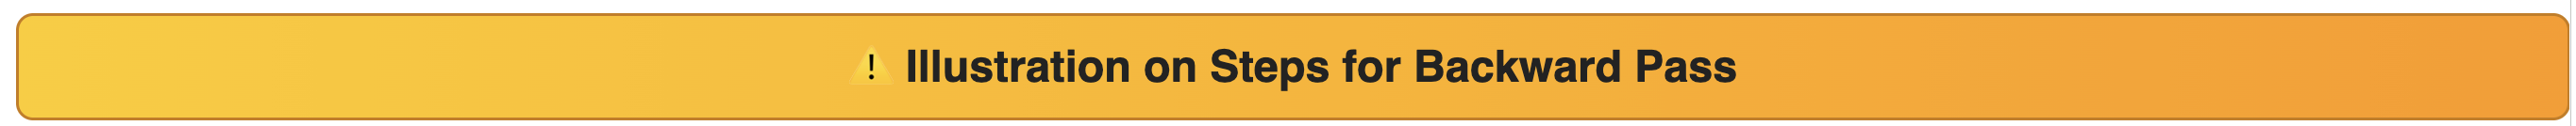

In [21]:
# True target value
y_true_val = 2.0

# -------------------------
# Forward pass
# -------------------------
z1 = x.dot(W1) + b1              # hidden layer weighted sum
a1 = np.maximum(0, z1)           # hidden layer activation (ReLU)
z2 = a1.dot(W2) + b2             # output layer weighted sum
y_hat = z2                       # linear output activation

# -------------------------
# Backward pass
# -------------------------

# 1. Gradient of MSE loss with respect to prediction
dL_dy_hat = 2 * (y_hat - y_true_val)

# 2. Output layer
# Linear activation means y_hat = z2, so:
dL_dz2 = dL_dy_hat

# Gradients for output-layer weights and bias
dL_dW2 = np.outer(a1, dL_dz2)
dL_db2 = dL_dz2

# 3. Hidden layer
# Send the error backward to the hidden layer
dL_da1 = dL_dz2.dot(W2.T)

# ReLU derivative: 1 where z1 > 0, otherwise 0
dL_dz1 = dL_da1 * (z1 > 0).astype(float)

# Gradients for hidden-layer weights and biases
dL_dW1 = np.outer(x, dL_dz1)
dL_db1 = dL_dz1

print("Prediction (y_hat):\n", y_hat)
print("Gradients W2:\n", dL_dW2)
print("Gradients b2:\n", dL_db2)
print("Gradients W1:\n", dL_dW1)
print("Gradients b1:\n", dL_db1)

Prediction (y_hat):
 [1.43]
Gradients W2:
 [[-2.622]
 [-0.   ]]
Gradients b2:
 [-1.14]
Gradients W1:
 [[-1.026  0.   ]
 [-1.368  0.   ]
 [ 0.684 -0.   ]]
Gradients b1:
 [-0.684  0.   ]


---

# 5. Learning rate and loss curves

Below we simulate three training-loss patterns.

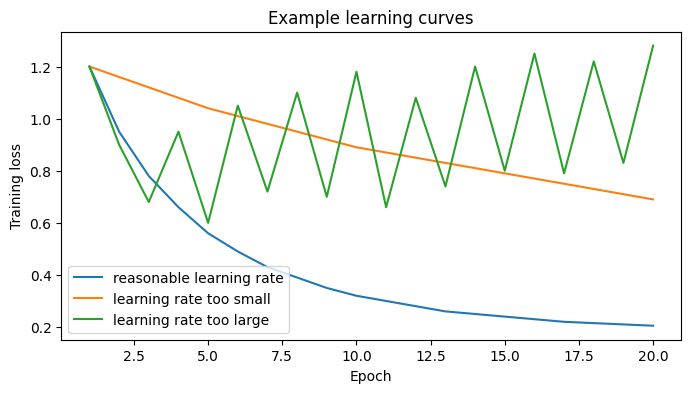

In [22]:
import matplotlib.pyplot as plt

epochs = np.arange(1, 21)

loss_good = np.array([1.20, 0.95, 0.78, 0.66, 0.56, 0.49, 0.43, 0.39, 0.35, 0.32,
                      0.30, 0.28, 0.26, 0.25, 0.24, 0.23, 0.22, 0.215, 0.210, 0.205])

loss_too_small = np.array([1.20, 1.16, 1.12, 1.08, 1.04, 1.01, 0.98, 0.95, 0.92, 0.89,
                           0.87, 0.85, 0.83, 0.81, 0.79, 0.77, 0.75, 0.73, 0.71, 0.69])

loss_too_large = np.array([1.20, 0.90, 0.68, 0.95, 0.60, 1.05, 0.72, 1.10, 0.70, 1.18,
                           0.66, 1.08, 0.74, 1.20, 0.80, 1.25, 0.79, 1.22, 0.83, 1.28])

plt.figure(figsize=(8, 4))
plt.plot(epochs, loss_good, label="reasonable learning rate")
plt.plot(epochs, loss_too_small, label="learning rate too small")
plt.plot(epochs, loss_too_large, label="learning rate too large")
plt.xlabel("Epoch")
plt.ylabel("Training loss")
plt.title("Example learning curves")
plt.legend()
plt.show()

---

# 6. Batch, stochastic, and mini-batch gradient descent

During training, we do not always update weights using the full dataset at once.

- **Batch gradient descent**: uses all observations before updating
- **Stochastic gradient descent (SGD)**: updates using one observation at a time
- **Mini-batch gradient descent**: updates using a small batch, such as 32 observations

An **epoch** means one full pass through the training data.

## Practice 6A: Concept check

Suppose a training set has 320 observations and the batch size is 32.

1. How many batches are processed in one epoch?
2. If the model trains for 10 epochs, how many total batches are processed?

In [23]:
### batch size processing is preferred
### 1) memory (not needing to process the whole data for a single step)
### 2) by using small datasets, we induce errors and that gets the process unstuck of local minima

n_obs = 320
batch_size = 32  ## lower, sometimes the better, but the slowest.
epochs = 10      ## number of times that the network goes over the whole data set

# TODO
batches_per_epoch = 320/32  ## really n_obs // batch_size
total_batches = 10*10 ## = 100 ## 100 batches are computed over the network

print("Batches per epoch =", batches_per_epoch)
print("Total batches =", total_batches)

Batches per epoch = 10.0
Total batches = 100


In [24]:
n_obs=670
batch_size=32

n_obs // batch_size

20

## Practice 6B: Short answer

Why is mini-batch gradient descent often preferred in practice?

**Your response here:**  


- computations
- better for gradient descent

---

# 7. Initializers, dropout, and regularization

Training also depends on how the model starts and how it avoids overfitting.

### Initializers
Weights are given starting values before training, such as:
- random normal
- random uniform
- Xavier / Glorot
- He initialization

### Dropout
Dropout randomly turns off a fraction of neurons during training.

### L1 / L2 regularization
These penalties discourage overly large weights.

### Optimizers
Optimizers determine how the model updates its weights during training based on the gradients from backpropagation.

Common examples include:
- **SGD (Stochastic Gradient Descent)**: updates weights in the direction that reduces the loss
- **Momentum**: helps SGD move faster in consistent directions
- **RMSprop**: adjusts learning rates based on recent gradient sizes
- **Adam**: combines ideas from Momentum and RMSprop, and is one of the most commonly used optimizers

In practice, different optimizers can lead to different training speed and performance.

## Practice 7A: Initialization concept

Why is setting **all weights to zero** usually a bad idea in a hidden layer?

**Your response here:**  


## Practice 7B: Dropout concept

If a model uses `Dropout(0.20)`, what does that mean during training?

**Your response here:**  


## Practice 7C: L1 vs L2

Which regularization method is more associated with pushing some coefficients all the way toward zero?

A. L1  
B. L2

L1 is associated with pushing coefficients to zero

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout ## feed-forward
from tensorflow.keras.regularizers import L1, L2

model = Sequential()
model.add(Input(shape = (3,)))
model.add(Dense(2, activation = "relu", kernel_initializer='glorot_uniform', bias_initializer='zeros', kernel_regularizer=L1()))
model.add(Dropout(0.2))
model.add(Dense(2, activation = "relu", kernel_initializer='glorot_uniform', bias_initializer='zeros'))
model.add(Dropout(0.1))
model.add(Dense(1))

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 2)              │             8 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 2)              │             6 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17 (68.00 B)

 Trainable params: 17 (68.00 B)

 Non-trainable params: 0 (0.00 B)

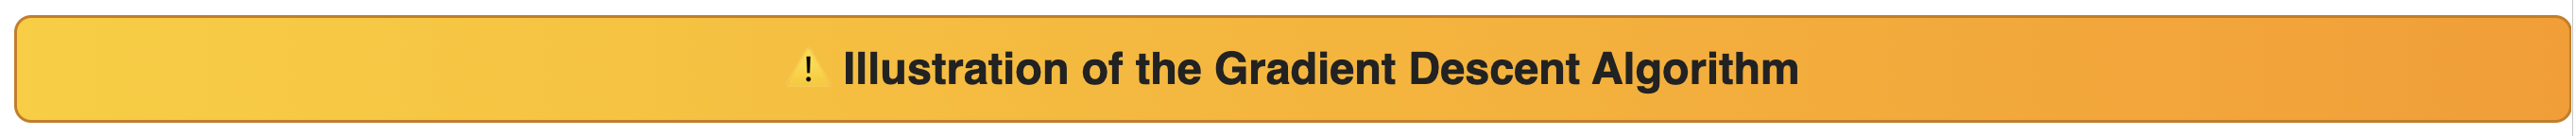

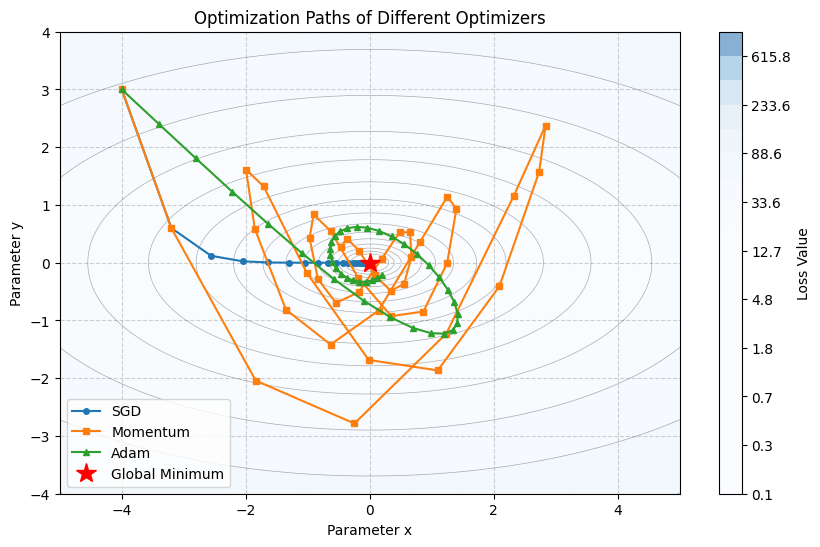

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define a simple 2D loss function (quadratic bowl) and its gradient
def f(x, y):
    return x**2 + 4*y**2

def grad_f(x, y):
    return np.array([2*x, 8*y])

start_pos = np.array([-4.0, 3.0])
iterations = 40

# 2. Vanilla SGD
lr_sgd = 0.1
pos_sgd = [start_pos]
w = start_pos.copy()
for _ in range(iterations):
    w = w - lr_sgd * grad_f(w[0], w[1])
    pos_sgd.append(w.copy())

# 3. SGD with Momentum
pos_mom = [start_pos]
w = start_pos.copy()
v = np.zeros(2)
gamma = 0.9
for _ in range(iterations):
    grad = grad_f(w[0], w[1])
    v = gamma * v + lr_sgd * grad
    w = w - v
    pos_mom.append(w.copy())

# 4. Adam Optimizer
pos_adam = [start_pos]
w = start_pos.copy()
m = np.zeros(2)
v_adam = np.zeros(2)
beta1, beta2 = 0.9, 0.999
epsilon = 1e-8
lr_adam = 0.6  # Adam usually uses a different learning rate scale
for t in range(1, iterations + 1):
    grad = grad_f(w[0], w[1])
    m = beta1 * m + (1 - beta1) * grad
    v_adam = beta2 * v_adam + (1 - beta2) * (grad**2)
    m_hat = m / (1 - beta1**t)
    v_hat = v_adam / (1 - beta2**t)
    w = w - lr_adam * m_hat / (np.sqrt(v_hat) + epsilon)
    pos_adam.append(w.copy())

# Convert to arrays for plotting
pos_sgd = np.array(pos_sgd)
pos_mom = np.array(pos_mom)
pos_adam = np.array(pos_adam)

# 5. Plotting the contour and paths
x_grid = np.linspace(-5, 5, 100)
y_grid = np.linspace(-4, 4, 100)
X, Y = np.meshgrid(x_grid, y_grid)
Z = f(X, Y)

plt.figure(figsize=(10, 6))

# Enhanced filled contours with a colorbar
cp_filled = plt.contourf(X, Y, Z, levels=np.logspace(-1, 3, 20), cmap='Blues', alpha=0.5)
cp_lines = plt.contour(X, Y, Z, levels=np.logspace(-1, 3, 20), colors='black', alpha=0.3, linewidths=0.5)
plt.colorbar(cp_filled, label='Loss Value')

plt.plot(pos_sgd[:, 0], pos_sgd[:, 1], 'o-', label='SGD', markersize=4)
plt.plot(pos_mom[:, 0], pos_mom[:, 1], 's-', label='Momentum', markersize=4)
plt.plot(pos_adam[:, 0], pos_adam[:, 1], '^-', label='Adam', markersize=4)

plt.plot(0, 0, 'r*', markersize=15, label='Global Minimum')
plt.title("Optimization Paths of Different Optimizers")
plt.xlabel("Parameter x")
plt.ylabel("Parameter y")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Starting point: [ 4.46081704 -2.36692618]


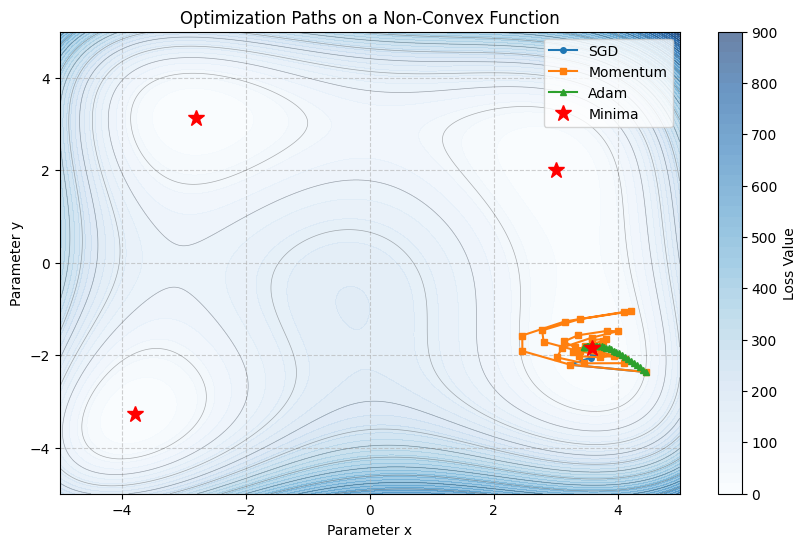

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define a non-convex 2D loss function (Himmelblau's function) and its gradient
def f(x, y):
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

def grad_f(x, y):
    df_dx = 4*x*(x**2 + y - 11) + 2*(x + y**2 - 7)
    df_dy = 2*(x**2 + y - 11) + 4*y*(x + y**2 - 7)
    return np.array([df_dx, df_dy])

# Random starting point
start_pos = np.random.uniform(low=-4.5, high=4.5, size=2)
print("Starting point:", start_pos)

iterations = 30

# 2. Vanilla SGD
lr_sgd = 0.01
pos_sgd = [start_pos]
w = start_pos.copy()
for _ in range(iterations):
    w = w - lr_sgd * grad_f(w[0], w[1])
    pos_sgd.append(w.copy())

# 3. SGD with Momentum
lr_mom = 0.01
gamma = 0.9
pos_mom = [start_pos]
w = start_pos.copy()
v = np.zeros(2)
for _ in range(iterations):
    grad = grad_f(w[0], w[1])
    v = gamma * v + lr_mom * grad
    w = w - v
    pos_mom.append(w.copy())

# 4. Adam Optimizer
lr_adam = 0.05
beta1, beta2 = 0.9, 0.999
epsilon = 1e-8
pos_adam = [start_pos]
w = start_pos.copy()
m = np.zeros(2)
v_adam = np.zeros(2)
for t in range(1, iterations + 1):
    grad = grad_f(w[0], w[1])
    m = beta1 * m + (1 - beta1) * grad
    v_adam = beta2 * v_adam + (1 - beta2) * (grad**2)
    m_hat = m / (1 - beta1**t)
    v_hat = v_adam / (1 - beta2**t)
    w = w - lr_adam * m_hat / (np.sqrt(v_hat) + epsilon)
    pos_adam.append(w.copy())

# Convert to arrays for plotting
pos_sgd = np.array(pos_sgd)
pos_mom = np.array(pos_mom)
pos_adam = np.array(pos_adam)

# 5. Plotting the contour and paths
x_grid = np.linspace(-5, 5, 400)
y_grid = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x_grid, y_grid)
Z = f(X, Y)

plt.figure(figsize=(10, 6))

cp_filled = plt.contourf(X, Y, Z, levels=50, cmap='Blues', alpha=0.6)
plt.contour(X, Y, Z, levels=20, colors='black', alpha=0.3, linewidths=0.5)
plt.colorbar(cp_filled, label='Loss Value')

plt.plot(pos_sgd[:, 0], pos_sgd[:, 1], 'o-', label='SGD', markersize=4)
plt.plot(pos_mom[:, 0], pos_mom[:, 1], 's-', label='Momentum', markersize=4)
plt.plot(pos_adam[:, 0], pos_adam[:, 1], '^-', label='Adam', markersize=4)

minima = np.array([
    [3.0, 2.0],
    [-2.805118, 3.131312],
    [-3.779310, -3.283186],
    [3.584428, -1.848126]
])
plt.plot(minima[:, 0], minima[:, 1], 'r*', markersize=12, label='Minima')

plt.title("Optimization Paths on a Non-Convex Function")
plt.xlabel("Parameter x")
plt.ylabel("Parameter y")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Starting point: [ 3.94797881 -2.6173618 ]


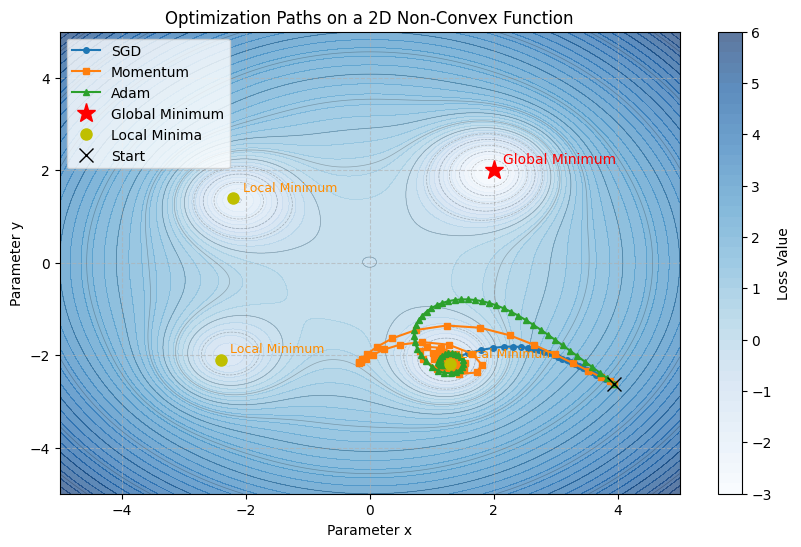

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define a 2D non-convex function and its gradient
def f(x, y):
    return (
        0.12 * (x**2 + y**2)
        - 3.8 * np.exp(-((x - 2.0)**2 + (y - 2.0)**2) / 0.9)
        - 2.8 * np.exp(-((x + 2.2)**2 + (y - 1.4)**2) / 0.8)
        - 2.4 * np.exp(-((x - 1.3)**2 + (y + 2.2)**2) / 0.7)
        - 2.1 * np.exp(-((x + 2.4)**2 + (y + 2.1)**2) / 0.9)
    )

def grad_f(x, y):
    # quadratic part
    df_dx = 0.24 * x
    df_dy = 0.24 * y

    # well 1
    e1 = np.exp(-((x - 2.0)**2 + (y - 2.0)**2) / 0.9)
    df_dx += 3.8 * e1 * (2 * (x - 2.0) / 0.9)
    df_dy += 3.8 * e1 * (2 * (y - 2.0) / 0.9)

    # well 2
    e2 = np.exp(-((x + 2.2)**2 + (y - 1.4)**2) / 0.8)
    df_dx += 2.8 * e2 * (2 * (x + 2.2) / 0.8)
    df_dy += 2.8 * e2 * (2 * (y - 1.4) / 0.8)

    # well 3
    e3 = np.exp(-((x - 1.3)**2 + (y + 2.2)**2) / 0.7)
    df_dx += 2.4 * e3 * (2 * (x - 1.3) / 0.7)
    df_dy += 2.4 * e3 * (2 * (y + 2.2) / 0.7)

    # well 4
    e4 = np.exp(-((x + 2.4)**2 + (y + 2.1)**2) / 0.9)
    df_dx += 2.1 * e4 * (2 * (x + 2.4) / 0.9)
    df_dy += 2.1 * e4 * (2 * (y + 2.1) / 0.9)

    return np.array([df_dx, df_dy])

# Random starting point
# np.random.seed(42)
start_pos = np.random.uniform(low=-4.0, high=4.0, size=2)
print("Starting point:", start_pos)

iterations = 60

# 2. Vanilla SGD
lr_sgd = 0.08
pos_sgd = [start_pos.copy()]
w = start_pos.copy()
for _ in range(iterations):
    w = w - lr_sgd * grad_f(w[0], w[1])
    pos_sgd.append(w.copy())

# 3. SGD with Momentum
lr_mom = 0.08
gamma = 0.9
pos_mom = [start_pos.copy()]
w = start_pos.copy()
v = np.zeros(2)
for _ in range(iterations):
    grad = grad_f(w[0], w[1])
    v = gamma * v + lr_mom * grad
    w = w - v
    pos_mom.append(w.copy())

# 4. Adam
lr_adam = 0.12
beta1, beta2 = 0.9, 0.999
epsilon = 1e-8
pos_adam = [start_pos.copy()]
w = start_pos.copy()
m = np.zeros(2)
v_adam = np.zeros(2)
for t in range(1, iterations + 1):
    grad = grad_f(w[0], w[1])
    m = beta1 * m + (1 - beta1) * grad
    v_adam = beta2 * v_adam + (1 - beta2) * (grad**2)
    m_hat = m / (1 - beta1**t)
    v_hat = v_adam / (1 - beta2**t)
    w = w - lr_adam * m_hat / (np.sqrt(v_hat) + epsilon)
    pos_adam.append(w.copy())

# Convert to arrays
pos_sgd = np.array(pos_sgd)
pos_mom = np.array(pos_mom)
pos_adam = np.array(pos_adam)

# 5. Approximate minima locations (the centers of the wells)
minima = np.array([
    [ 2.0,  2.0],   # deepest -> global minimum
    [-2.2,  1.4],   # local minimum
    [ 1.3, -2.2],   # local minimum
    [-2.4, -2.1]    # local minimum
])

# 6. Plot contours and paths
x_grid = np.linspace(-5, 5, 400)
y_grid = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(x_grid, y_grid)
Z = f(X, Y)

plt.figure(figsize=(10, 6))

cp_filled = plt.contourf(X, Y, Z, levels=50, cmap="Blues", alpha=0.65)
plt.contour(X, Y, Z, levels=20, colors="black", alpha=0.25, linewidths=0.5)
plt.colorbar(cp_filled, label="Loss Value")

plt.plot(pos_sgd[:, 0], pos_sgd[:, 1], 'o-', label='SGD', markersize=4)
plt.plot(pos_mom[:, 0], pos_mom[:, 1], 's-', label='Momentum', markersize=4)
plt.plot(pos_adam[:, 0], pos_adam[:, 1], '^-', label='Adam', markersize=4)

# Mark minima
plt.plot(minima[0, 0], minima[0, 1], 'r*', markersize=14, label='Global Minimum')
plt.text(minima[0, 0] + 0.15, minima[0, 1] + 0.15, "Global Minimum", color="red", fontsize=10)

plt.plot(minima[1:, 0], minima[1:, 1], 'yo', markersize=8, label='Local Minima')
for mx, my in minima[1:]:
    plt.text(mx + 0.15, my + 0.15, "Local Minimum", color="darkorange", fontsize=9)

plt.plot(start_pos[0], start_pos[1], 'kx', markersize=10, label='Start')

plt.title("Optimization Paths on a 2D Non-Convex Function")
plt.xlabel("Parameter x")
plt.ylabel("Parameter y")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

---

# 8. Regression example with the house-price dataset

We will use the attached house-price dataset:

- `square_feet`
- `bedrooms`
- `distance_to_city`
- target: `price`

In [29]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/martinwg/ISA630/refs/heads/master/data/NN_house_prices.csv")
df.head()

,square_feet,bedrooms,distance_to_city,price
0,2174,4,24.1,335078
1,1952,4,10.0,362952
2,2227,4,7.9,398657
3,2533,4,21.8,378778
4,1918,3,6.4,363453


In [30]:
df.describe()

,square_feet,bedrooms,distance_to_city,price
count,200.000000,200.00000,200.000000,200.000000
mean,1985.745000,3.01000,13.058500,345763.530000
std,325.867655,1.07034,7.067907,50431.302264
min,1083.000000,1.00000,1.300000,225215.000000
25%,1753.000000,2.00000,6.875000,312778.500000
50%,1998.500000,3.00000,13.050000,342042.000000
75%,2175.500000,4.00000,19.025000,379748.250000
max,2952.000000,5.00000,25.000000,499965.000000


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[["square_feet", "bedrooms", "distance_to_city"]]
y = df["price"]

X_train, X_test, y_train, yhy_test_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

house_scaler = StandardScaler()
X_train = house_scaler.fit_transform(X_train)
X_test = house_scaler.transform(X_test)

print(X_train.shape, X_test.shape)

(150, 3) (50, 3)


## Practice 8B: Build a regression model in Keras

Build a network with:

- input shape = `(3,)`
- hidden layer 1 = 16 neurons, ReLU
- hidden layer 2 = 8 neurons, tanh
- output layer = 1 neuron, linear

Compile with:
- optimizer = `"adam"`
- loss = `"mse"`

In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout

model = Sequential()
model.add(Input(shape=(3,)))
model.add(Dense(16, activation="relu"))
model.add(Dense(8, activation="tanh"))
model.add(Dense(1, activation="linear"))

model.compile(optimizer="adam", loss="mse")
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209 (836.00 B)

 Trainable params: 209 (836.00 B)

 Non-trainable params: 0 (0.00 B)

## Practice 8C: Train the regression model

Train for up to 100 epochs with:
- `validation_split=0.2`
- `batch_size=16`
- `verbose=1`

Use early stopping with:
- monitor = `"val_loss"`
- patience = 10
- restore_best_weights = True

In [36]:
## first create early stopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

## next fit the model and add the callback
model.fit(X_train, y_train, validation_split=0.2, batch_size=16, verbose=1, callbacks=[early_stop], epochs=100)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - loss: 123342610432.0000 - val_loss: 111238275072.0000
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 123342561280.0000 - val_loss: 111238217728.0000
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 123342512128.0000 - val_loss: 111238168576.0000
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 123342454784.0000 - val_loss: 111238127616.0000
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 123342405632.0000 - val_loss: 111238070272.0000
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 123342348288.0000 - val_loss: 111238021120.0000
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 123342299136.0000 - val_loss: 111237963776.0000
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 123342241792.0000 - val_loss: 111237922816.0000
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 123342192640.0000 - val_loss: 111237873664.0000
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/

## Practice 8D: Plot the learning curves

Plot:
- training loss
- validation loss

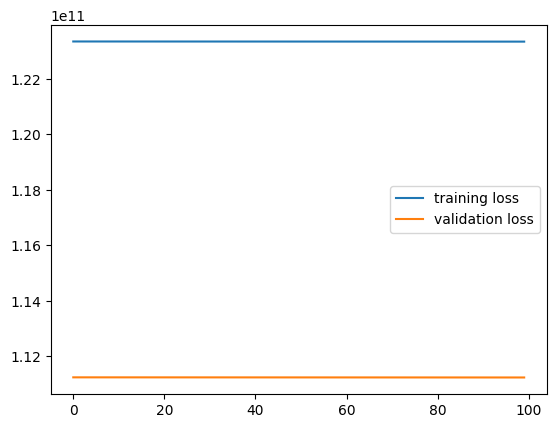

In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout
from tensorflow.keras.optimizers import Adam

model = Sequential()
model.add(Input(shape=(3,)))
model.add(Dense(16, activation="relu"))
model.add(Dense(8, activation="relu"))
model.add(Dense(1, activation="linear"))

model.compile(optimizer= Adam(learning_rate=0.1), loss="mse")

## first create early stopping
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

## next fit the model and add the callback
model.fit(X_train, y_train, validation_split=0.2, batch_size=16, verbose=1, callbacks=[early_stop], epochs=100)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 58ms/step - loss: 123336531968.0000 - val_loss: 111186386944.0000
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 123191107584.0000 - val_loss: 110885363712.0000
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 122643955712.0000 - val_loss: 109995130880.0000
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 121181609984.0000 - val_loss: 107966398464.0000
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 118007291904.0000 - val_loss: 104051859456.0000
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 112347398144.0000 - val_loss: 97444503552.0000
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 102990061568.0000 - val_loss: 87394353152.0000
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 89560211456.0000 - val_loss: 73652166656.0000
Epoch 9/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 72446369792.0000 - val_loss: 56740265984.0000
Epoch 10/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step -

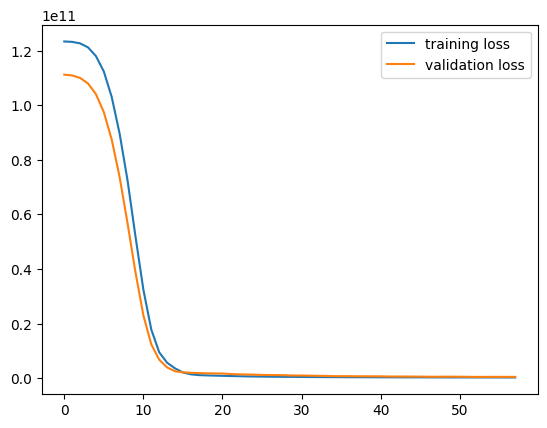

In [46]:
## plot learning curves
import matplotlib.pyplot as plt

history = model.history
plt.plot(history.history["loss"], label="training loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.legend()
plt.show()

---

# 9. Multi-class classification example with customer segments

We will use the attached customer-segment dataset:

- `monthly_spend`
- `website_visits`
- `support_tickets`
- target: `customer_segment`

In [47]:

cust_df = pd.read_csv("https://raw.githubusercontent.com/martinwg/ISA630/refs/heads/master/data/NN_customer_segment.csv")
cust_df.head()

,monthly_spend,website_visits,support_tickets,customer_segment
0,368.01,14,4,Basic
1,659.63,24,3,Standard
2,559.62,18,4,Basic
3,309.12,11,3,Basic
4,439.00,29,1,Standard


In [48]:
cust_df["customer_segment"].value_counts()

,count
customer_segment,
Basic,99
Standard,88
Premium,13


In [49]:
from sklearn.preprocessing import LabelEncoder

X_cust = cust_df[["monthly_spend", "website_visits", "support_tickets"]].copy()
y_cust = cust_df["customer_segment"].copy()

label_encoder = LabelEncoder()
y_cust_encoded = label_encoder.fit_transform(y_cust)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cust, y_cust_encoded, test_size=0.25, random_state=42, stratify=y_cust_encoded
)

cust_scaler = StandardScaler()
Xc_train_scaled = cust_scaler.fit_transform(Xc_train)
Xc_test_scaled = cust_scaler.transform(Xc_test)

print("Classes:", list(label_encoder.classes_))
print(Xc_train_scaled.shape, Xc_test_scaled.shape)

Classes: ['Basic', 'Premium', 'Standard']
(150, 3) (50, 3)


## Practice 9B: Build a multi-class model in Keras

Build a network with:

- input shape = `(3,)`
- hidden layer 1 = 16 neurons, ReLU
- hidden layer 2 = 8 neurons, tanh
- output layer = 3 neurons, softmax

Compile with:
- optimizer = `"adam"`
- loss = `"sparse_categorical_crossentropy"`
- metrics = `["accuracy"]`

In [51]:
## build the multi-class model

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Dropout

model = Sequential()
model.add(Input(shape=(3,)))
model.add(Dense(16, activation="relu"))
model.add(Dense(8, activation="tanh"))
model.add(Dense(3, activation="softmax"))

model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_27 (Dense)                │ (None, 16)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 3)              │            27 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 227 (908.00 B)

 Trainable params: 227 (908.00 B)

 Non-trainable params: 0 (0.00 B)

## Practice 9C: Train the classification model

Train for up to 100 epochs with:
- `validation_split=0.2`
- `batch_size=16`
- `verbose=1`

Use early stopping again.

In [53]:
## callback
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

## fit
model.fit(Xc_train_scaled, yc_train, validation_split=0.2, batch_size = 16, verbose=1, callbacks=[early_stop], epochs=100)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.7250 - loss: 0.7277 - val_accuracy: 0.6667 - val_loss: 0.7323
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7250 - loss: 0.7170 - val_accuracy: 0.6667 - val_loss: 0.7230
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7333 - loss: 0.7059 - val_accuracy: 0.6667 - val_loss: 0.7137
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.7333 - loss: 0.6967 - val_accuracy: 0.7000 - val_loss: 0.7068
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.7333 - loss: 0.6882 - val_accuracy: 0.7000 - val_loss: 0.7019
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7333 - loss: 0.6809 - val_accuracy: 0.7000 - val_loss: 0.6939
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.7333 - loss: 0.6723 - val_accuracy: 0.7000 - val_loss: 0.6888
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.7333 - loss: 0.6660 - val_accuracy: 0.7000 - val_loss:

## Practice 9D: Plot the classification learning curves

Plot:
- training loss
- validation loss

Optional: also plot accuracy and validation accuracy.

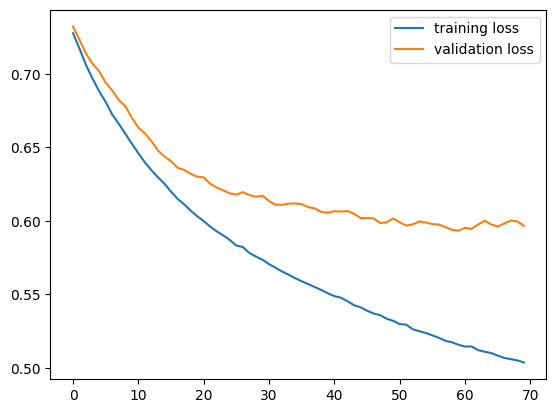

In [54]:
## plot learning curves
import matplotlib.pyplot as plt

history = model.history
plt.plot(history.history["loss"], label="training loss")
plt.plot(history.history["val_loss"], label="validation loss")
plt.legend()
plt.show()

---

# 10. Quiz-style review

Complete the following without using the self-check cells right away.

### Review 1
A weight has current value `1.20`, gradient `-0.40`, and learning rate `0.05`.  
What is the updated weight?

### Review 2
A training curve drops very slowly over many epochs.  
What is one possible issue?

### Review 3
A model’s validation loss begins rising while training loss keeps falling.  
What issue might this suggest?

### Review 4
For a multi-class classification problem with 4 classes, what output activation is commonly used?

### Review 5
If a dataset has 640 training observations and batch size is 64, how many batches are there in one epoch?

In [56]:
# 1)
old_weight = 1.20
gradient = -0.40
learning_rate = 0.05
new_weight = old_weight - learning_rate * gradient



# TODO: answer the review questions
review1 = new_weight
review2 = "small learning rate"
review3 = "starting to overfit"
review4 = "softmax"
review5 = 10

print("Review 1:", review1)
print("Review 2:", review2)
print("Review 3:", review3)
print("Review 4:", review4)
print("Review 5:", review5)

Review 1: 1.22
Review 2: small learning rate
Review 3: starting to overfit
Review 4: softmax
Review 5: 10
